Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Better plotting style
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


Create Dataset

In [2]:
# Number of samples
n_samples = 200

# Input feature
X = np.linspace(-3, 3, n_samples).reshape(-1, 1)

# Gaussian noise
noise = np.random.normal(0, 0.1, n_samples).reshape(-1, 1)

# Target values
y = np.sin(X) + noise

print("Input shape :", X.shape)
print("Target shape:", y.shape)

Input shape : (200, 1)
Target shape: (200, 1)


Visualize Dataset

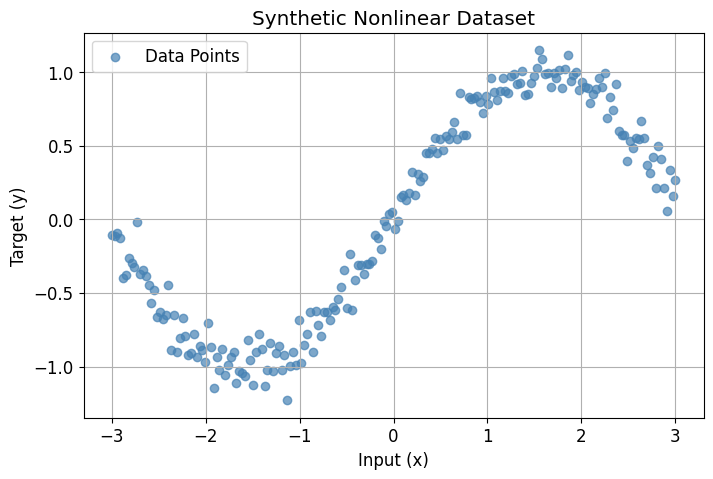

In [4]:
plt.figure()

plt.scatter(
    X,
    y,
    color="steelblue",
    alpha=0.7,
    label="Data Points"
)

plt.title("Synthetic Nonlinear Dataset")
plt.xlabel("Input (x)")
plt.ylabel("Target (y)")
plt.legend()
plt.grid(True)

plt.show()

Linear Regression Class

In [5]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate

        # Initialize parameters
        self.w = np.random.randn(1, 1) * 0.01
        self.b = np.zeros((1,))

        self.loss_history = []


    # Prediction

    def predict(self, X):
        return X @ self.w + self.b


    # Mean Squared Error

    def compute_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)


    # Compute Gradients

    def compute_gradients(self, X, y_true, y_pred):

        n = len(X)

        error = y_pred - y_true

        dw = (2 / n) * (X.T @ error)

        db = (2 / n) * np.sum(error)

        return dw, db


    # Gradient Descent Update

    def update_parameters(self, dw, db):

        self.w -= self.lr * dw
        self.b -= self.lr * db


    # Training Loop

    def fit(self, X, y, epochs=1000, print_every=100):

        for epoch in range(epochs):

            predictions = self.predict(X)

            loss = self.compute_loss(y, predictions)

            dw, db = self.compute_gradients(
                X,
                y,
                predictions
            )

            self.update_parameters(dw, db)

            self.loss_history.append(loss)

            if epoch % print_every == 0:
                print(f"Epoch {epoch:4d} | Loss = {loss:.6f}")

Train Linear Regression

In [6]:
# Train Linear Regression

linear_model = LinearRegressionScratch(
    learning_rate=0.01
)

linear_model.fit(
    X,
    y,
    epochs=1000,
    print_every=100
)

Epoch    0 | Loss = 0.569058
Epoch  100 | Loss = 0.183471
Epoch  200 | Loss = 0.183468
Epoch  300 | Loss = 0.183468
Epoch  400 | Loss = 0.183468
Epoch  500 | Loss = 0.183468
Epoch  600 | Loss = 0.183468
Epoch  700 | Loss = 0.183468
Epoch  800 | Loss = 0.183468
Epoch  900 | Loss = 0.183468
